<a href="https://colab.research.google.com/github/silvatria/pembelajaran-mesin-254107023001/blob/main/JS04_SOAL_KUIS1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [2]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [4]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [5]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# Data Size
df.shape

(48842, 15)

In [7]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [10]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# 1. Inspeksi profile data (missing value)
print("Jumlah missing value per kolom:")
print(df.isnull().sum())

# 2. Cek juga apakah ada missing value dalam bentuk simbol khusus seperti '?' pada kolom kategorikal
print("\nJumlah simbol '?' per kolom:")
print((df == '?').sum())

Jumlah missing value per kolom:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Jumlah simbol '?' per kolom:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [12]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Ubah simbol '?' menjadi np.nan
df.replace('?', np.nan, inplace=True)

# Melakukan data imputation menggunakan penugasan langsung untuk menghindari FutureWarning
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Cek kembali apakah masih terdapat data yang hilang
print("Sisa missing value setelah imputation:")
print(df.isnull().sum().sum())

Sisa missing value setelah imputation:
0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [13]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Inspeksi unique value pada semua fitur kualitatif (kategorikal)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"Kolom {col}:")
    print(df[col].unique())
    print("-" * 40)

# Menyesuaikannya jika ada duplikasi penulisan atau nilai tidak sesuai (contoh pada 'income')
df['income'] = df['income'].replace({'<=50K.': '<=50K', '>50K.': '>50K'})

Kolom workclass:
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
----------------------------------------
Kolom education:
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
----------------------------------------
Kolom marital-status:
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
----------------------------------------
Kolom occupation:
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
----------------------------------------
Kolom relationship:
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
---------------------------

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

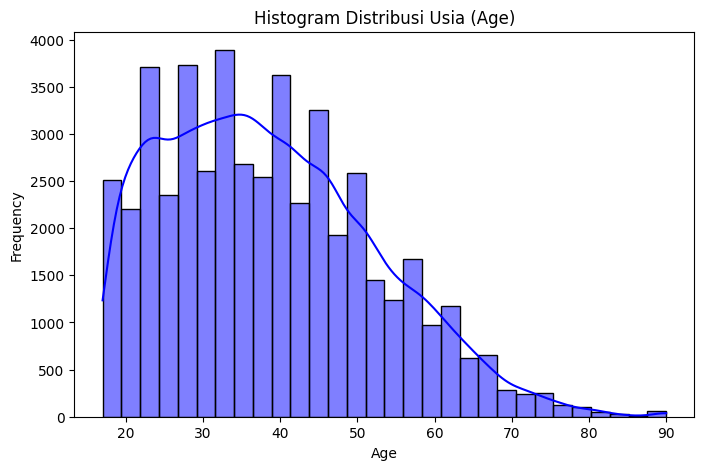

In [14]:
# Jawab 1.1 - Histrogram

plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Histogram Distribusi Usia (Age)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

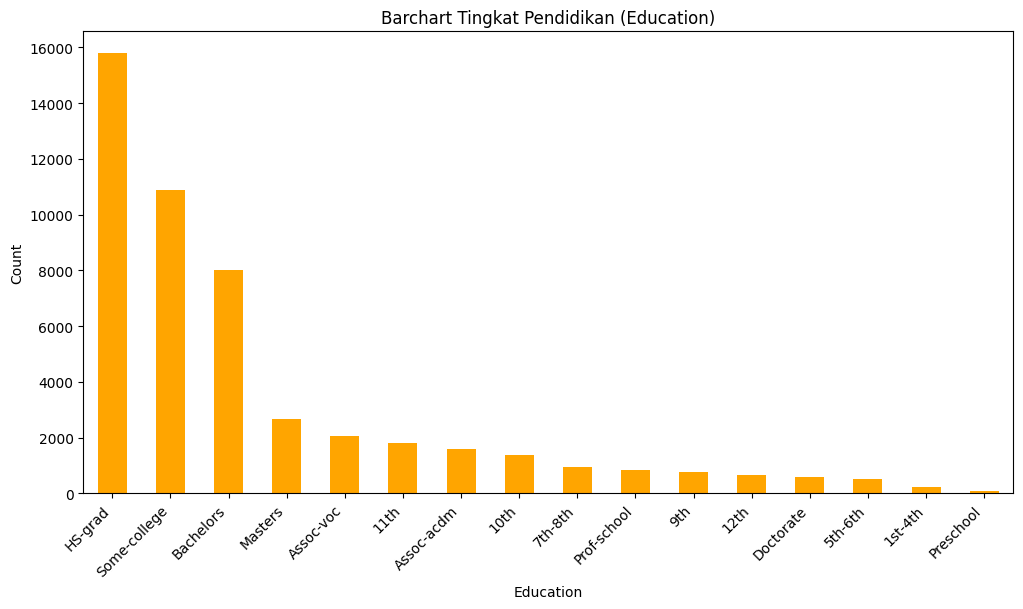

In [15]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(12, 6))
df['education'].value_counts().plot(kind='bar', color='orange')
plt.title('Barchart Tingkat Pendidikan (Education)')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

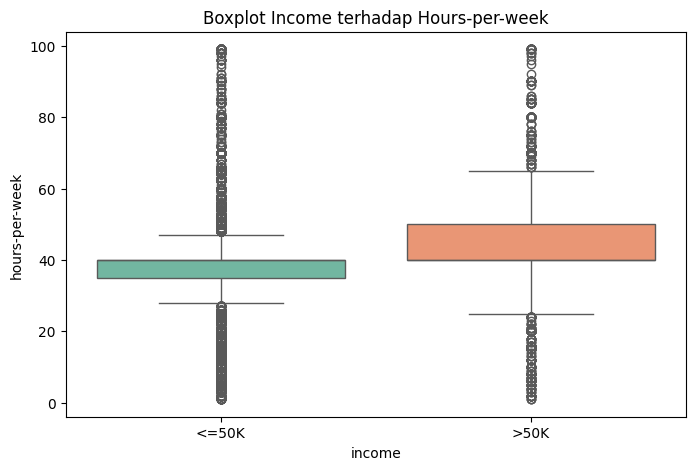

In [17]:
# Jawab 1.3 - Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x='income', y='hours-per-week', data=df, hue='income', palette='Set2', legend=False)
plt.title('Boxplot Income terhadap Hours-per-week')
plt.show()

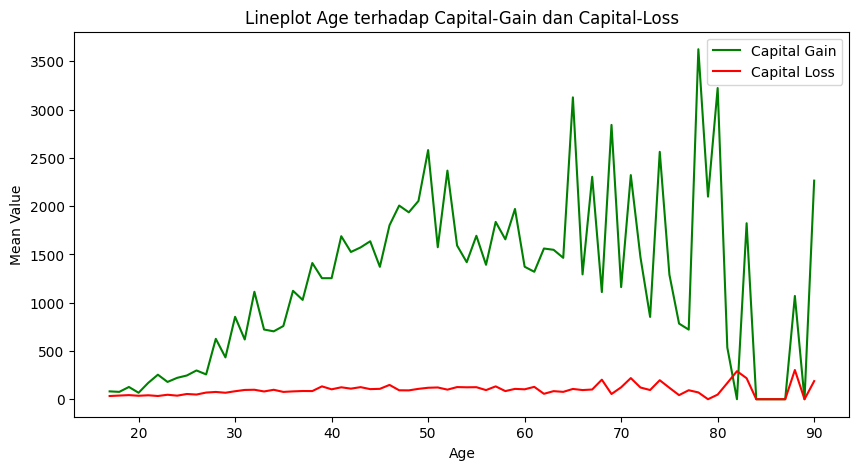

In [18]:
# Jawab 1.4 - Lineplot
plt.figure(figsize=(10, 5))
# Mengelompokkan rata-rata capital-gain dan capital-loss berdasarkan age untuk lineplot
df_grouped = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

plt.plot(df_grouped['age'], df_grouped['capital-gain'], label='Capital Gain', color='green')
plt.plot(df_grouped['age'], df_grouped['capital-loss'], label='Capital Loss', color='red')
plt.title('Lineplot Age terhadap Capital-Gain dan Capital-Loss')
plt.xlabel('Age')
plt.ylabel('Mean Value')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [19]:
# Jawab dengan komentar python

'''
  1. Fenomena pada distribusi data 'age':
     Distribusi usia cenderung right-skewed (miring ke kanan), di mana jumlah penduduk usia muda (20-40 tahun)
     lebih mendominasi, dan berangsur-angsur menurun pada usia lanjut.

  2. Strategi penanganan missing value pada variabel 'age':
     Jika ada data hilang pada 'age', dapat diimputasi menggunakan median atau mean dari data tersebut.
     Median lebih disukai jika distribusi datanya skewed agar tidak mudah terpengaruh oleh outlier.

  3. Jumlah outlier dan kategori 'income' terbanyak outlier:
     Berdasarkan boxplot hours-per-week terhadap income, kedua kelompok income (<=50K dan >50K) memiliki
     banyak outlier (terutama pada jam kerja < 40 atau > 40 jam). Kelompok pendapatan <=50K biasanya
     memiliki jumlah titik outlier absolut yang lebih banyak secara volume karena ukuran populasinya yang lebih besar.
'''

"\n  1. Fenomena pada distribusi data 'age': \n     Distribusi usia cenderung right-skewed (miring ke kanan), di mana jumlah penduduk usia muda (20-40 tahun) \n     lebih mendominasi, dan berangsur-angsur menurun pada usia lanjut.\n  \n  2. Strategi penanganan missing value pada variabel 'age': \n     Jika ada data hilang pada 'age', dapat diimputasi menggunakan median atau mean dari data tersebut. \n     Median lebih disukai jika distribusi datanya skewed agar tidak mudah terpengaruh oleh outlier.\n  \n  3. Jumlah outlier dan kategori 'income' terbanyak outlier: \n     Berdasarkan boxplot hours-per-week terhadap income, kedua kelompok income (<=50K dan >50K) memiliki \n     banyak outlier (terutama pada jam kerja < 40 atau > 40 jam). Kelompok pendapatan <=50K biasanya \n     memiliki jumlah titik outlier absolut yang lebih banyak secara volume karena ukuran populasinya yang lebih besar.\n"

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [20]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Encoding kolom 'sex'
df['sex'] = le.fit_transform(df['sex'])

# Encoding kolom target 'income'
df['income'] = le.fit_transform(df['income'])

print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

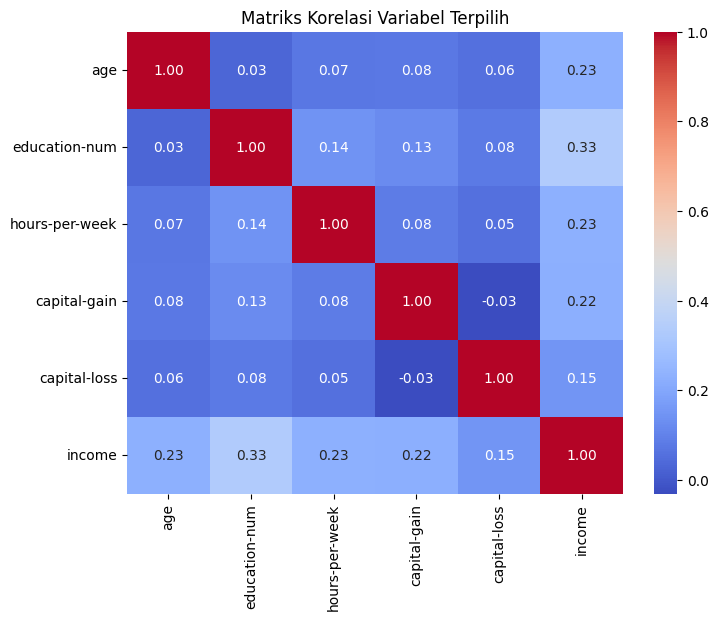

In [21]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

selected_vars = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']
corr_matrix = df[selected_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Variabel Terpilih')
plt.show()

In [22]:
# Hasil analisis jelaskan pada cell ini

''' - Variabel 'education-num' dan 'age' menunjukkan korelasi positif yang cukup berarti terhadap 'income'.
    - 'hours-per-week' juga memiliki hubungan positif dengan tingkat pendapatan, menunjukkan bahwa orang dengan jam kerja lebih tinggi
    cenderung memiliki probabilitas pendapatan >50K lebih besar. '''

" - Variabel 'education-num' dan 'age' menunjukkan korelasi positif yang cukup berarti terhadap 'income'.\n    - 'hours-per-week' juga memiliki hubungan positif dengan tingkat pendapatan, menunjukkan bahwa orang dengan jam kerja lebih tinggi \n    cenderung memiliki probabilitas pendapatan >50K lebih besar. "

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [23]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


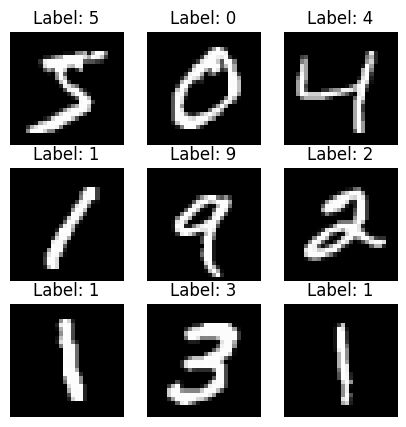

In [24]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

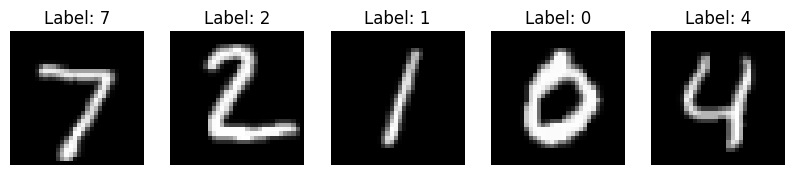

In [25]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

import cv2

# Ukuran test data (10000 data)
num_samples = X_test.shape[0]
X_test_upsampled = np.zeros((num_samples, 32, 32), dtype=np.float32)

for i in range(num_samples):
    # Melakukan resize dari 28x28 ke 32x32 menggunakan INTER_LINEAR
    X_test_upsampled[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_LINEAR)

# Tampilkan 5 data hasil upsampling
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [26]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

X_test_normalized = X_test_upsampled / 255.0

print("Nilai minimum:", X_test_normalized.min(), "Nilai maksimum:", X_test_normalized.max())

Nilai minimum: 0.0 Nilai maksimum: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [27]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Ukuran citra sekarang 32x32 = 1024 fitur per sampel
X_test_flattened = X_test_normalized.reshape(X_test_normalized.shape[0], -1)

print("Shape data test setelah flatten:", X_test_flattened.shape)

Shape data test setelah flatten: (10000, 1024)
